In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Simulación e histograma

In [ ]:
def prop():
  global c
  cont = 0
  N = 1
  while cont == 0:
    xr = np.random.uniform()
    if xr > c:
      N += 1
    else:
      cont += 1
  return N

def propT():
  global c
  N = 1
  xr = np.random.uniform()
  if xr > c:
    N += prop()
    xr = np.random.uniform()
    if xr > c:
      N += prop()

  return N

# def propT():
#   global c
#   N = 1
#   xr = np.random.uniform()
#   if xr > c:
#     N += prop()
#   xr = np.random.uniform()
#   if xr > c:
#     N += prop()

#   return N

In [ ]:
Nsim = 1_000

c = 0.1
res = []
for i in range(Nsim):
  Ninf = propT()
  res.append(Ninf)

Nmax = max(res) + 1
freq = np.zeros(Nmax)
for i in range(Nsim):
  itmp = res[i]
  freq[itmp] += 1

In [ ]:
freq = pd.read_csv("frecuencias_con_c_0_punto_1_1e9_simulaciones.txt", header=None) #246
freq2 = pd.read_csv("frecuencias_con_c_0_punto_5_1e9_simulaciones.txt", header=None) #246
freq3 = pd.read_csv("frecuencias_con_c_0_punto_8_1e9_simulaciones.txt", header=None) #246
freq4 = pd.read_csv("prueba.txt", header=None) #24


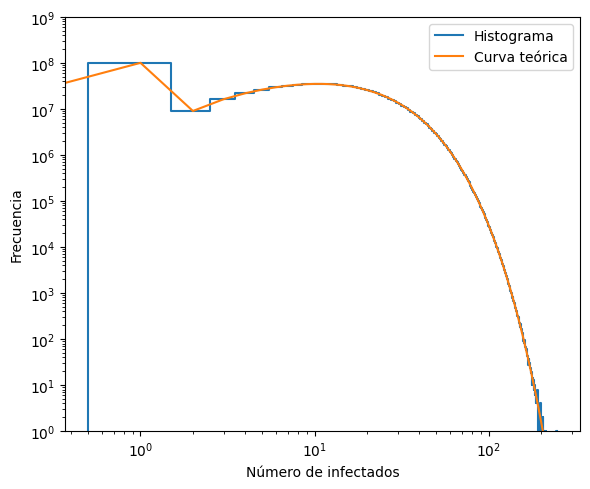

In [ ]:
c = 0.1
xtmp = np.arange(246)
ftest = (xtmp-1)*c**2*(1-c)**(xtmp-1)
ftest[1] = c

plt.figure(figsize=(6,5))
plt.step(xtmp, freq[0], where = 'mid', label = 'Histograma')
plt.plot(xtmp, 1E9*ftest, label = 'Curva teórica')

plt.legend()
plt.ylim(1,1E9)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Número de infectados')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.savefig("histograma1.jpg", dpi=300)
plt.show()

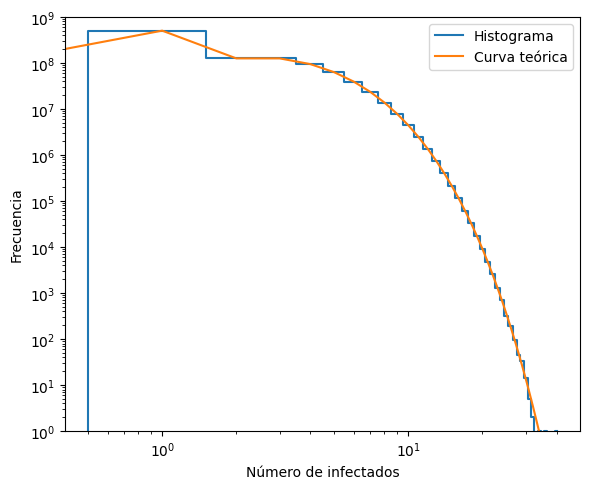

In [ ]:
c = 0.5
xtmp = np.arange(41)
ftest = (xtmp-1)*c**2*(1-c)**(xtmp-1)
ftest[1] = c

plt.figure(figsize=(6,5))
plt.step(xtmp, freq2[0], where = 'mid', label = 'Histograma')
plt.plot(xtmp, 1E9*ftest, label = 'Curva teórica')
plt.legend()
plt.ylim(1,1E9)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Número de infectados')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.savefig("histograma0punto5.jpg", dpi=300)
plt.show()

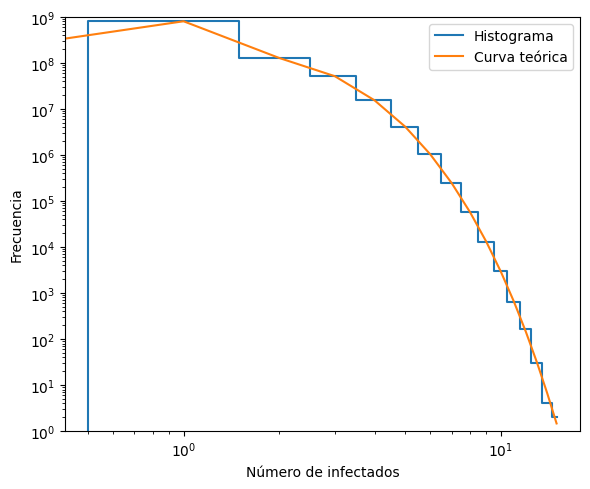

In [ ]:
c = 0.8
xtmp = np.arange(16)
ftest = (xtmp-1)*c**2*(1-c)**(xtmp-1)
ftest[1] = c
plt.figure(figsize=(6,5))
plt.step(xtmp, freq3[0], where = 'mid', label = 'Histograma')
plt.plot(xtmp, 1E9*ftest, label = 'Curva teórica')

plt.legend()
plt.ylim(1,1E9)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Número de infectados')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.savefig("histograma0punto8.jpg", dpi=300)
plt.show()

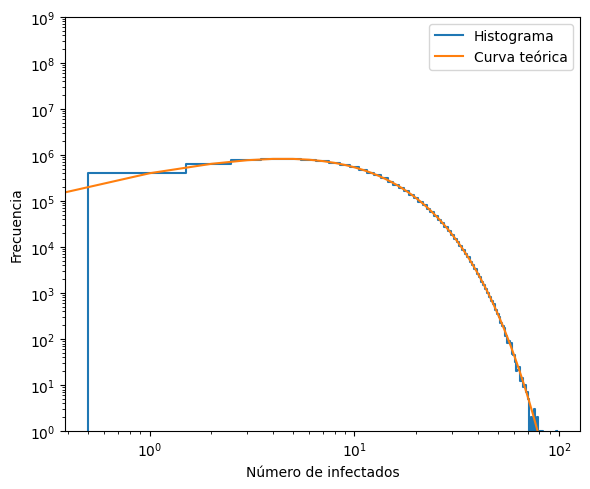

In [ ]:
#Otro modelo
c = 0.2
xtmp = np.arange(98)
ftest = (xtmp)*c**2*(1-c)**(xtmp-1)

plt.figure(figsize=(6,5))
plt.step(xtmp, freq4[0], where = 'mid', label = 'Histograma')
plt.plot(xtmp, 1E7*ftest, label = 'Curva teórica')
#plt.plot(xtmp, 1E9*ftest2, label = 'Curva teórica 2')
plt.legend()
plt.ylim(1,1E9)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Número de infectados')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.savefig("histograma1.jpg", dpi=300)
plt.show()

# Extra

$$ \frac{c^2(1-c)}{2c^2(1-c)/(1+c)} = \frac{c^2(1-c)(1+c)}{2c^2(1-c)} = \frac{1+c}{2} = \frac{1.1}{2} = 0.55$$

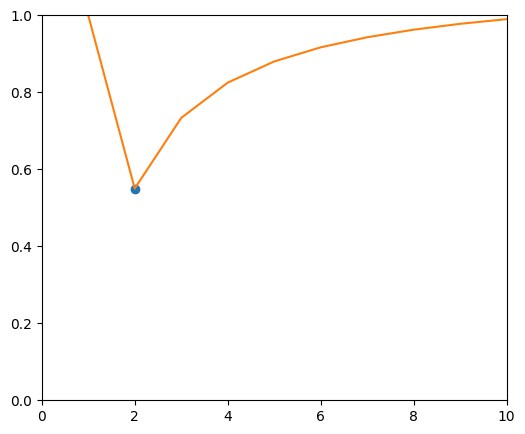

In [ ]:
xtmp = np.arange(246) #246
ftest = (xtmp)*c**2*(1-c)**(xtmp-1)/(1+c)
#ftest = (xtmp-1)*c**2*(1-c)**(xtmp-1) #La normalizacion es 1
ftest[1] = c

n = freq[0]/(ftest*1E9)

plt.figure(figsize=(6,5))
plt.plot(2,0.55, 'o')
plt.plot(xtmp, n)
plt.ylim(0,1)
plt.xlim(0,10)
plt.show()

# Tamaño medio de la infección

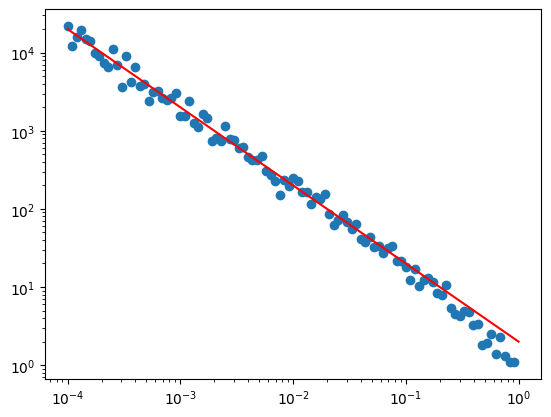

In [ ]:
ctmp = np.logspace(0,4,100, endpoint=False)/1E4
Nsim = 10
res = []

for i in range(100):
  c = ctmp[i]
  Smean = 0.0

  for i in range(Nsim):
    Ninf = propT()
    Smean = (i*Smean + Ninf)/(i+1)
  res.append(Smean)

xtmp = np.linspace(0.0001,1,1000)

plt.scatter(ctmp, res)
plt.plot(xtmp, 2/xtmp, c = 'red')
plt.xscale('log')
plt.yscale('log')
plt.show()


In [ ]:
media = pd.read_csv("valor_medio_distintas_c.txt", header=None)

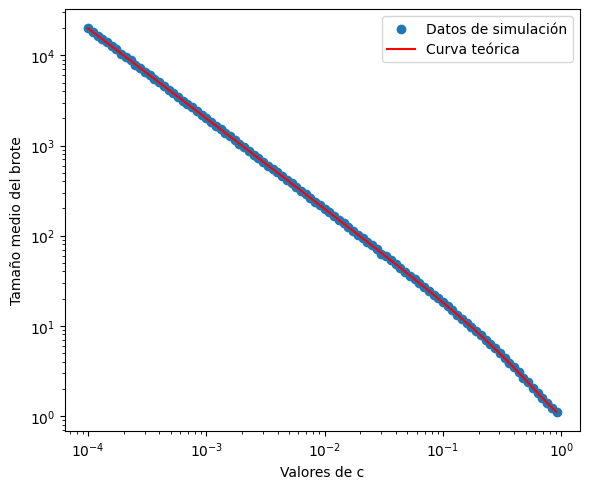

In [ ]:
ctmp = np.logspace(0,4,100, endpoint=False)/1E4

media_teorica = ctmp + (2-ctmp-ctmp**3)/(ctmp*(1+ctmp))
media_teorica2 = -2 + ctmp + (2/ctmp)

plt.figure(figsize=(6,5))
plt.scatter(ctmp,media, label='Datos de simulación')
#plt.plot(ctmp, media_teorica, color='blue', label="c + (2-c-c**3)/(c*(1+c))")
plt.plot(ctmp, media_teorica2, color='red', label="Curva teórica")
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Valores de c')
plt.ylabel('Tamaño medio del brote')
plt.legend()
plt.tight_layout()
plt.savefig("tamano_mediosinlog.jpg", dpi=300)
plt.show()


# Longitud de correlacion


In [ ]:
Ninfmax = 1_000
def conteo(Ninf, freq):
    global Ninfmax
    if Ninf < Ninfmax:
        freq[0] += Ninf
        for j in range(1,Ninf):
            freq[j] += 2 * (Ninf - j)


In [ ]:
#Modificamos la simulacion
Nsim = 10_000
c = 0.2
freq = np.zeros(Ninfmax)
xtmp = np.arange(Ninfmax)

for i in range(Nsim):
    Ninf = propT()
    conteo(Ninf, freq)
rmean = np.sum(xtmp*freq)/np.sum(freq)
print(rmean)

6.132828413534245


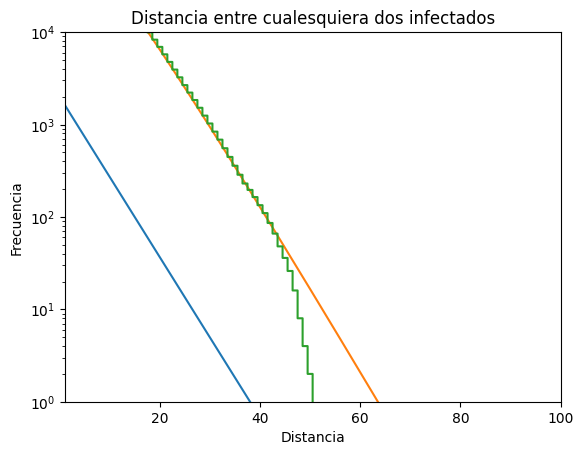

In [ ]:
# a = np.zeros_like(xtmp, dtype=float)
# a[0] = Nsim * (c*c - 2*c + 2) / c
# r = xtmp[1:]
# a[1:] = Nsim * ( 2 * (1-c)**r * ( c*r + 2*(1-c) ) / c )

b = Nsim  *2* (1 - c)**(xtmp) * (c*xtmp + 2*(1 - c)) / c
plt.plot(xtmp, Nsim*c*np.exp(-xtmp*c))
plt.plot(xtmp, b)
plt.step(xtmp, freq, where = 'mid')
plt.xlim(1,1E2)
plt.ylim(1, Nsim)
plt.yscale('log')

plt.title('Distancia entre cualesquiera dos infectados')
plt.xlabel('Distancia')
plt.ylabel('Frecuencia')

plt.show()

In [ ]:
freqr = pd.read_csv("freq_distancia_c_0.2_1e8_sim_v1.txt", header=None)
freqr02v2 = pd.read_csv("freq_distancia_c_0.2_1e8_sim_v2.txt", header=None)
freqr02v3 = pd.read_csv("freq_distancia_c_0.2_1e8_sim_v3.txt", header=None)
freqr05 = pd.read_csv("freq_distancia_c_0.5_1e8_sim.txt", header=None)
freqr05v2 = pd.read_csv("freq_distancia_c_0.5_1e8_sim_v2.txt", header=None)
freqr05v3 = pd.read_csv("freq_distancia_c_0.5_1e8_sim_v3.txt", header=None)


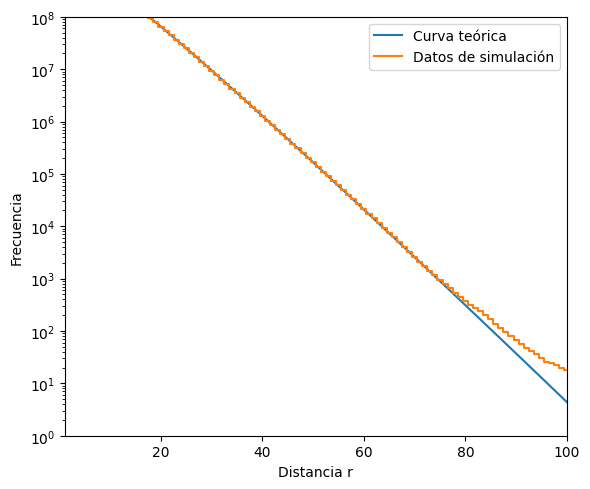

In [ ]:
xtmp = np.arange(100_000)
Nsim = 100_000_000
c = 0.2
b = Nsim  *2* (1 - c)**(xtmp) * (c*xtmp + 2*(1 - c)) / c

plt.figure(figsize=(6,5))
plt.plot(xtmp, b, label = 'Curva teórica')
plt.step(xtmp, freqr, where = 'mid', label = 'Datos de simulación')
plt.xlim(1, 1e2)
plt.ylim(1, Nsim)
plt.yscale('log')
plt.xlabel('Distancia r')
plt.ylabel('Frecuencia')
plt.legend()

plt.tight_layout()
plt.savefig("distancia_r_0.2_1e8.jpg", dpi=300)

plt.show()

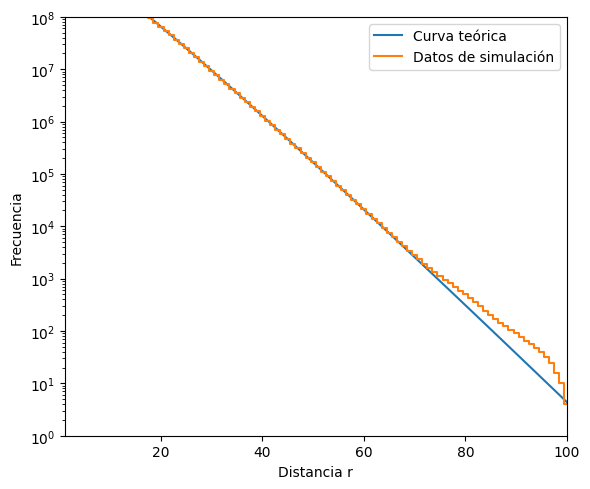

In [ ]:
xtmp = np.arange(10_000)
Nsim = 100_000_000
c = 0.2
b = Nsim  *2* (1 - c)**(xtmp) * (c*xtmp + 2*(1 - c)) / c

plt.figure(figsize=(6,5))
plt.plot(xtmp, b, label = 'Curva teórica')
plt.step(xtmp, freqr02v2, where = 'mid', label = 'Datos de simulación')
plt.xlim(1, 1e2)
plt.ylim(1, Nsim)
plt.yscale('log')
plt.xlabel('Distancia r')
plt.ylabel('Frecuencia')
plt.legend()

plt.tight_layout()
plt.savefig("distancia_r_0.2_1e8_v2.jpg", dpi=300)

plt.show()

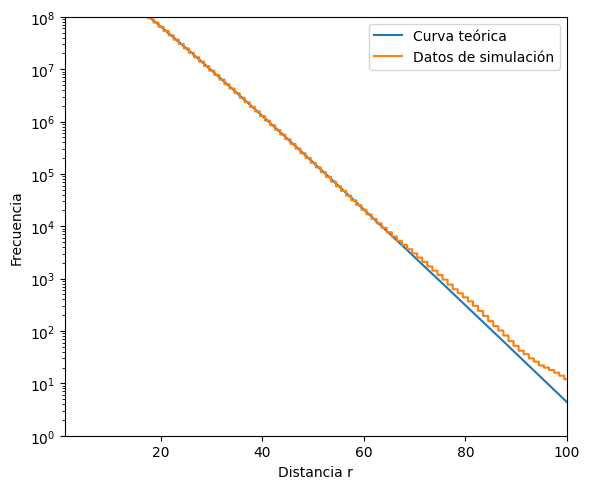

In [ ]:
xtmp = np.arange(1_000)
Nsim = 100_000_000
c = 0.2
b = Nsim  *2* (1 - c)**(xtmp) * (c*xtmp + 2*(1 - c)) / c

plt.figure(figsize=(6,5))
plt.plot(xtmp, b, label = 'Curva teórica')
plt.step(xtmp, freqr02v3, where = 'mid', label = 'Datos de simulación')
plt.xlim(1, 1e2)
plt.ylim(1, Nsim)
plt.yscale('log')
plt.xlabel('Distancia r')
plt.ylabel('Frecuencia')
plt.legend()

plt.tight_layout()
plt.savefig("distancia_r_0.2_1e8_v3.jpg", dpi=300)

plt.show()

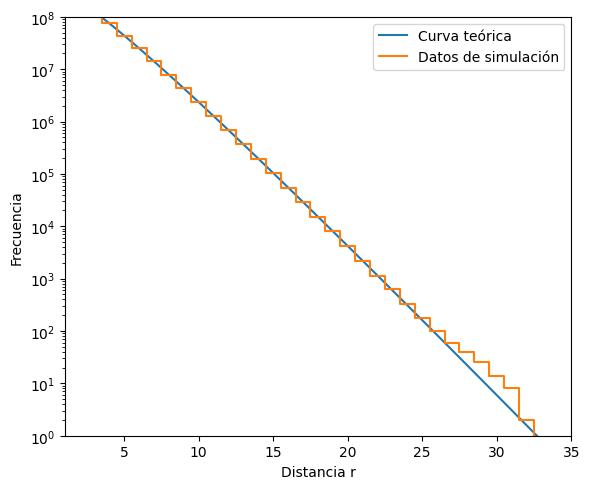

In [ ]:
xtmp = np.arange(10_000)
Nsim = 100_000_000
c = 0.5
b = Nsim  *2* (1 - c)**(xtmp) * (c*xtmp + 2*(1 - c)) / c

plt.figure(figsize=(6,5))
plt.plot(xtmp, b, label = 'Curva teórica')
plt.step(xtmp, freqr05, where = 'mid', label = 'Datos de simulación')
plt.xlim(1, 35)
plt.ylim(1, Nsim)
plt.yscale('log')
plt.xlabel('Distancia r')
plt.ylabel('Frecuencia')
plt.legend()

plt.tight_layout()
plt.savefig("distancia_r_0.5_1e8.jpg", dpi=300)

plt.show()

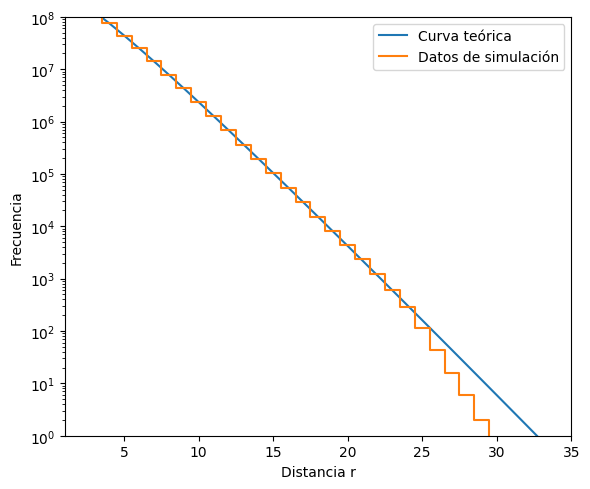

In [ ]:
xtmp = np.arange(100_000)
Nsim = 100_000_000
c = 0.5
b = Nsim  *2* (1 - c)**(xtmp) * (c*xtmp + 2*(1 - c)) / c

plt.figure(figsize=(6,5))
plt.plot(xtmp, b, label = 'Curva teórica')
plt.step(xtmp, freqr05v2, where = 'mid', label = 'Datos de simulación')
plt.xlim(1, 35)
plt.ylim(1, Nsim)
plt.yscale('log')
plt.xlabel('Distancia r')
plt.ylabel('Frecuencia')
plt.legend()

plt.tight_layout()
plt.savefig("distancia_r_0.5_1e8_v2.jpg", dpi=300)

plt.show()

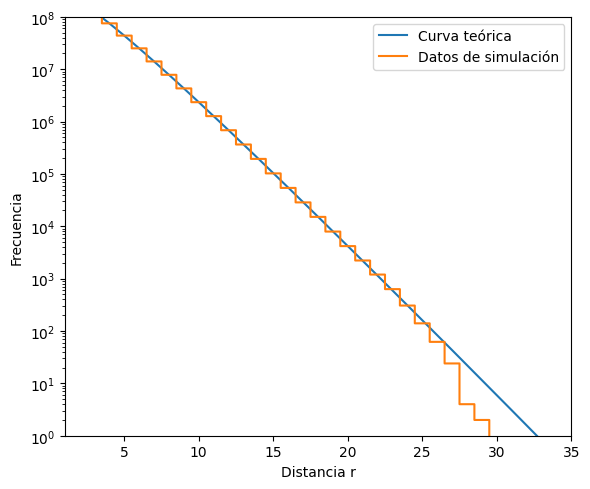

In [ ]:
xtmp = np.arange(1_000)
Nsim = 100_000_000
c = 0.5
b = Nsim  *2* (1 - c)**(xtmp) * (c*xtmp + 2*(1 - c)) / c

plt.figure(figsize=(6,5))
plt.plot(xtmp, b, label = 'Curva teórica')
plt.step(xtmp, freqr05v3, where = 'mid', label = 'Datos de simulación')
plt.xlim(1, 35)
plt.ylim(1, Nsim)
plt.yscale('log')
plt.xlabel('Distancia r')
plt.ylabel('Frecuencia')
plt.legend()

plt.tight_layout()
plt.savefig("distancia_r_0.5_1e8_v3.jpg", dpi=300)

plt.show()

In [ ]:
ctmp = np.logspace(0,4,100, endpoint=False)/1E4
res = []
for c in ctmp:
    freq = np.zeros(Ninfmax)

    for i in range(Nsim):
        Ninf = propT()
        conteo(Ninf, freq)
    rmean = np.sum(xtmp*freq)/np.sum(freq)
    res.append(rmean)
a = (8 - 14*ctmp + 6*ctmp**2) / ( ctmp * (ctmp**3 + 2*ctmp**2 - 8*ctmp + 6) )

plt.scatter(ctmp, res)
plt.plot(ctmp, a)
plt.xscale('log')
plt.yscale('log')

plt.tight_layout()
plt.savefig("distancia_r_0.5_1e8.jpg", dpi=300)
plt.show()
#Aumentar el cutoff

In [ ]:
rmean1 = pd.read_csv("rmean_coff_1e3_sim_1e4_v1.txt", header=None)
rmean2 = pd.read_csv("rmean_coff_1e4_sim_1e4_v1.txt", header=None)
rmean3 = pd.read_csv("rmean_coff_1e5_sim_1e4_v1.txt", header=None)


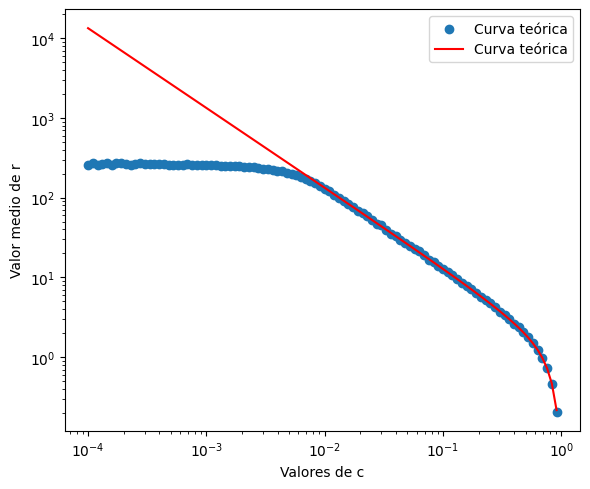

In [ ]:
a = (8 - 14*ctmp + 6*ctmp**2) / ( ctmp * (ctmp**3 + 2*ctmp**2 - 8*ctmp + 6) )
ctmp = np.logspace(0,4,100, endpoint=False)/1E4

plt.figure(figsize=(6,5))
plt.scatter(ctmp, rmean1, label = 'Curva teórica')
plt.plot(ctmp, a, label = 'Curva teórica', color='red')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Valores de c')
plt.ylabel('Valor medio de r')
plt.legend()

plt.tight_layout()
plt.savefig("rmean_coff_1e3.jpg", dpi=300)
plt.show()

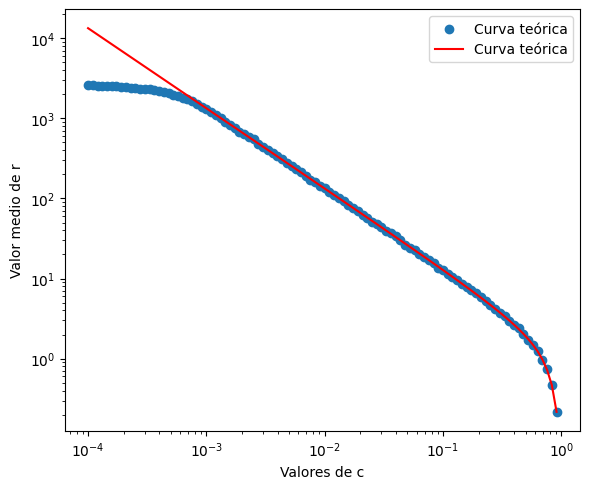

In [ ]:
a = (8 - 14*ctmp + 6*ctmp**2) / ( ctmp * (ctmp**3 + 2*ctmp**2 - 8*ctmp + 6) )
ctmp = np.logspace(0,4,100, endpoint=False)/1E4

plt.figure(figsize=(6,5))
plt.scatter(ctmp, rmean2, label = 'Curva teórica')
plt.plot(ctmp, a, label = 'Curva teórica', color='red')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Valores de c')
plt.ylabel('Valor medio de r')
plt.legend()

plt.tight_layout()
plt.savefig("rmean_coff_1e4.jpg", dpi=300)
plt.show()

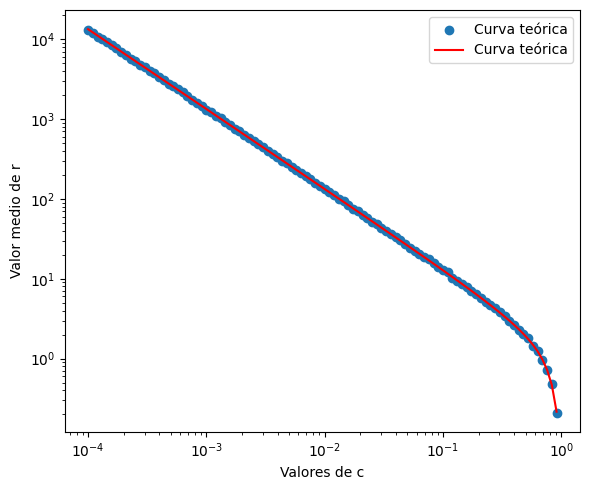

In [ ]:
a = (8 - 14*ctmp + 6*ctmp**2) / ( ctmp * (ctmp**3 + 2*ctmp**2 - 8*ctmp + 6) )
ctmp = np.logspace(0,4,100, endpoint=False)/1E4

plt.figure(figsize=(6,5))
plt.scatter(ctmp, rmean3, label = 'Curva teórica')
plt.plot(ctmp, a, label = 'Curva teórica', color='red')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Valores de c')
plt.ylabel('Valor medio de r')
plt.legend()

plt.tight_layout()
plt.savefig("rmean_coff_1e5.jpg", dpi=300)
plt.show()

/tmp/ipython-input-2605796556.py:11: RuntimeWarning: divide by zero encountered in divide
  Er1 = (8 - 14*c + 6*c**2) / (c * D)
/tmp/ipython-input-2605796556.py:14: RuntimeWarning: divide by zero encountered in divide
  Er2 = (2 * (3*c**2 - 7*c + 4)) / (c * D)
/tmp/ipython-input-2605796556.py:15: RuntimeWarning: divide by zero encountered in divide
  Er2 = 4/(3*c)


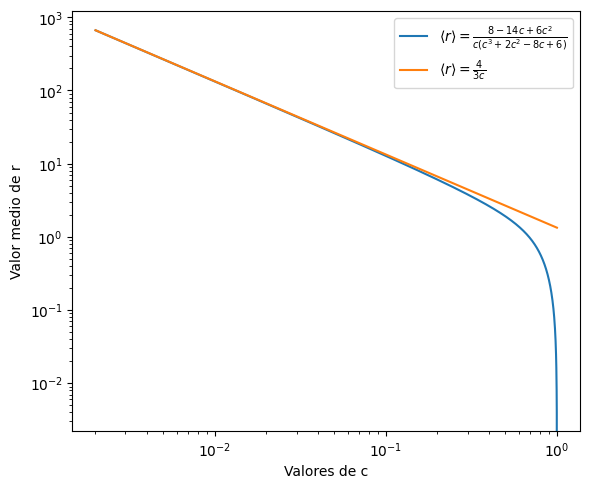

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Valores de c
c = np.linspace(0, 1, 500)  # evitamos c=0 y c=1 exactos

# Denominador común
D = c**3 + 2*c**2 - 8*c + 6

# Forma 1: sin factorizar
Er1 = (8 - 14*c + 6*c**2) / (c * D)

# Forma 2: factorizada
Er2 = (2 * (3*c**2 - 7*c + 4)) / (c * D)
Er2 = 4/(3*c)

# Graficar
plt.figure(figsize=(6,5))
plt.plot(c, Er1, label=r'$\langle r\rangle = \frac{8 - 14c + 6c^2}{c(c^3 + 2c^2 - 8c + 6)}$', linestyle='-')
plt.plot(c, Er2, label=r'$\langle r\rangle = \frac{4}{3c}$', linestyle='-')


plt.xlabel('Valores de c')
plt.ylabel('Valor medio de r')
plt.xscale('log')
plt.yscale('log')
plt.legend()

plt.tight_layout()
plt.savefig("xi_vs_r.jpg", dpi=300)
plt.show()
